In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

# Set Chinese display
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = 'black'   # Spine color
plt.rcParams['axes.linewidth'] = 1.0       # Spine width
plt.rcParams['axes.grid'] = False        # Master switch

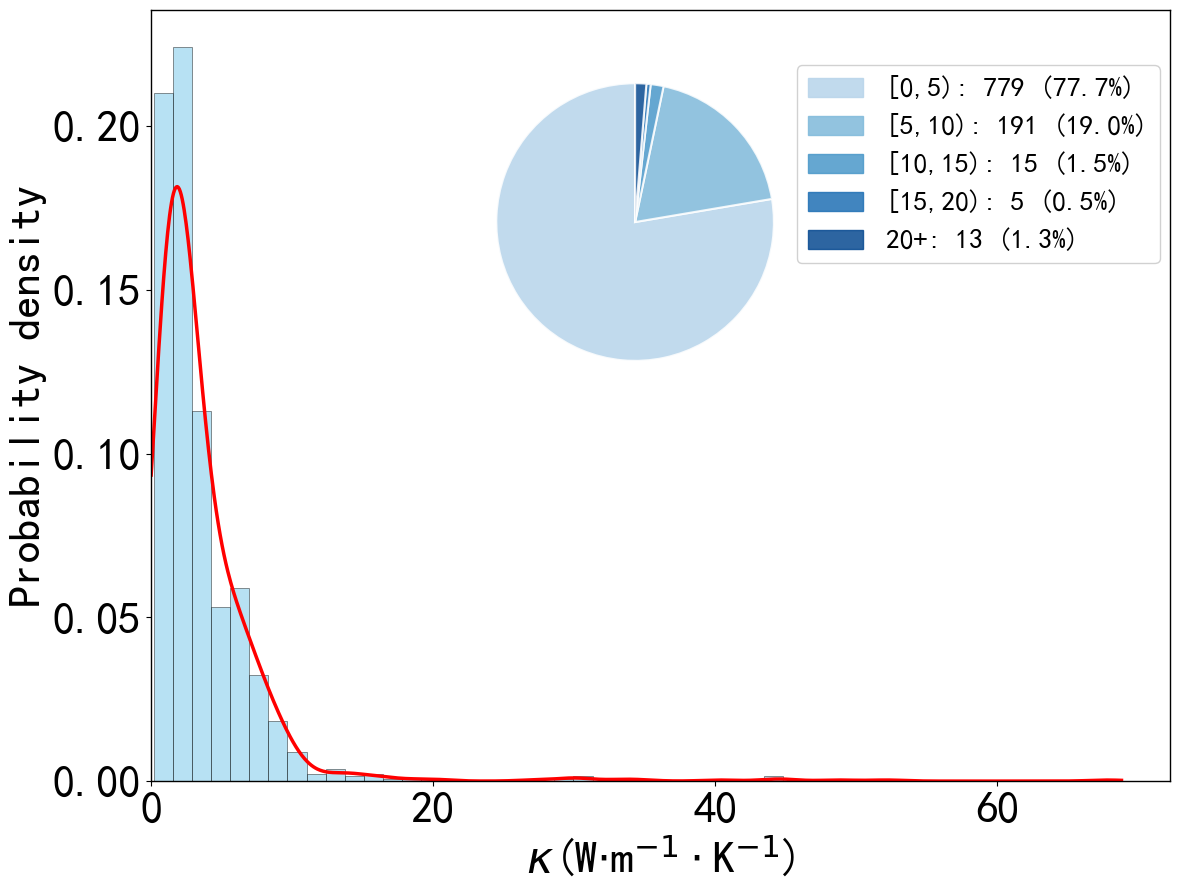

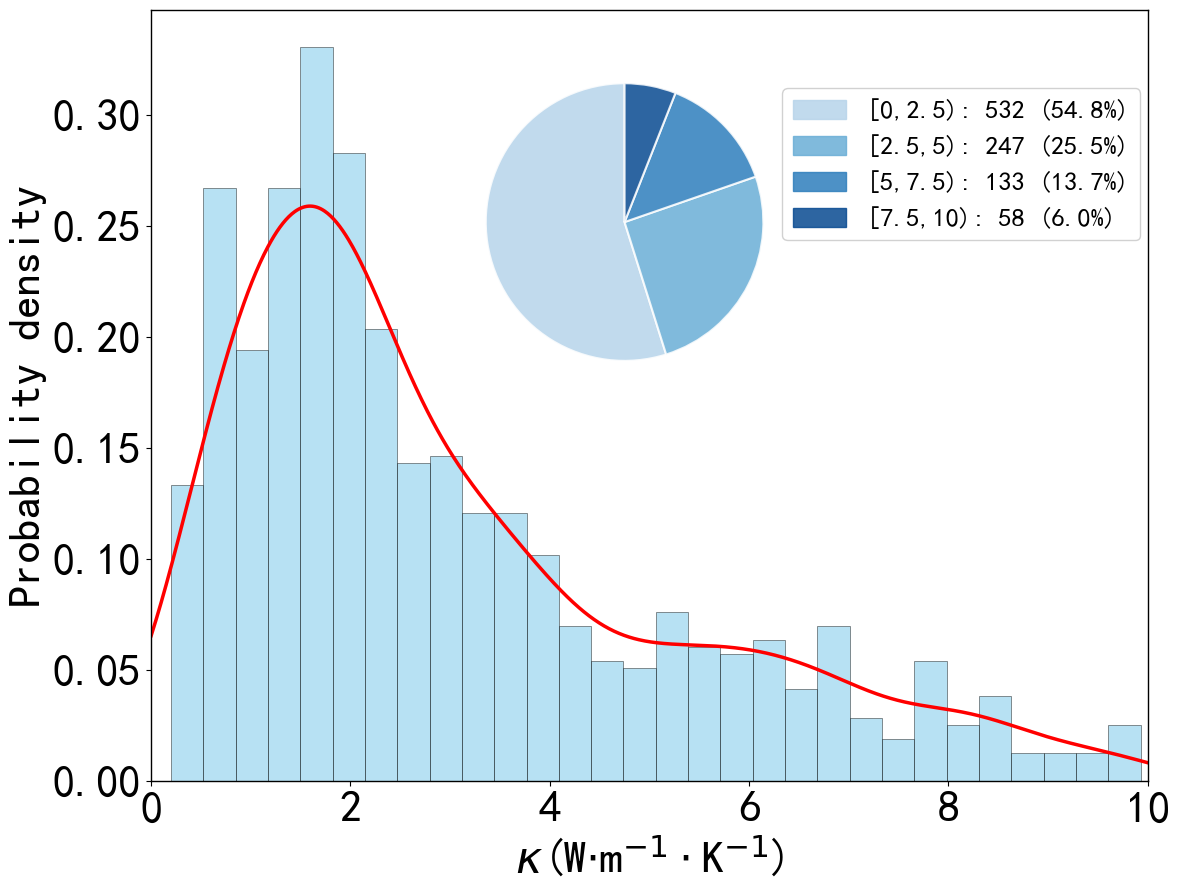

In [4]:
# Read data
df = pd.read_csv('csv/df_k.csv')
kl_values = df['k(W/mK)'].dropna()

# Set intervals (as requested)
bins = [0, 5, 10, 15, 20, np.inf]
bin_labels = ['[0,5)', '[5,10)', '[10,15)', '[15,20)', '20+']

# Count quantity and percentage in each interval
kl_categories = pd.cut(kl_values, bins=bins, labels=bin_labels, right=False)
kl_distribution = kl_categories.value_counts().sort_index()
percentages = (kl_distribution.values / len(kl_values) * 100).round(1)

# Create figure
fig, ax = plt.subplots(figsize=(14, 9))

# Plot probability density distribution
# Histogram
n, bin_edges, patches = ax.hist(kl_values, bins=50, density=True, alpha=0.6,
                                 color='skyblue', edgecolor='black', linewidth=0.5)

# KDE curve
kde = gaussian_kde(kl_values)
x_vals = np.linspace(max(0, kl_values.min() - 1), kl_values.max() + 1, 1000)
ax.plot(x_vals, kde(x_vals), 'r-', linewidth=2.5)

# Set figure properties
ax.set_xlabel(r'$\kappa$(W$\cdot$m$^{-1}\cdot$K$^{-1}$)', fontsize=32)
ax.set_ylabel('Probability density', fontsize=32)
# ax.set_title('Lattice thermal conductivity (kl) probability density distribution', fontsize=15, fontweight='bold', pad=20)
# Set axis font size
ax.tick_params(axis='both', labelsize=32)

# Set axis range
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Create larger nested pie chart in upper right corner
pie_ax = ax.inset_axes([0.25, 0.5, 0.45, 0.45])  # Increase pie chart size [x, y, width, height]

# Set pie chart colors (using gradient colors)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(kl_distribution)))

# Draw pie chart, do not display percentage text
wedges, texts, autotexts = pie_ax.pie(
    kl_distribution.values,
    labels=None,  # Do not display labels on pie chart
    colors=colors,
    explode=None,  # Cancel highlight
    autopct='',    # Do not display percentage
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'alpha': 0.85}
)

# Remove pie chart title
# pie_ax.set_title('') - Do not use title at all

# Hide pie chart axes
pie_ax.axis('off')

# Add percentage for each interval inside pie chart (optional, can be commented out if not needed)
# Here we follow your request, do not display percentages on the figure

# Display detailed distribution in legend
legend_labels = [f'{label}: {count} ({pct}%)'
                 for label, count, pct in zip(kl_distribution.index, kl_distribution.values, percentages)]

# Create custom legend
legend_patches = [mpatches.Patch(color=color, label=label, alpha=0.85)
                  for color, label in zip(colors, legend_labels)]

# Add legend to right side of main figure
ax.legend(handles=legend_patches,
          loc='center left', bbox_to_anchor=(0.62, 0.8),
          fontsize=20, framealpha=0.9, title_fontsize=16)

# Adjust layout, leave space for right side legend
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave 15% space on right for legend

plt.savefig('png/k+.png', dpi=100, bbox_inches='tight')
# Display figure
plt.show()


kl_values_filtered = kl_values[kl_values < 10]

# Set intervals
bins = [0, 2.5, 5, 7.5, 10]
bin_labels = ['[0,2.5)', '[2.5,5)', '[5,7.5)', '[7.5,10)']

# Count quantity and percentage in each interval
kl_categories = pd.cut(kl_values_filtered, bins=bins, labels=bin_labels, right=False)
kl_distribution = kl_categories.value_counts().sort_index()
percentages = (kl_distribution.values / len(kl_values_filtered) * 100).round(1)

# Create figure
fig, ax = plt.subplots(figsize=(14, 9))

# Plot probability density distribution - only use data less than 20
# Histogram
n, bin_edges, patches = ax.hist(kl_values_filtered, bins=30, density=True, alpha=0.6,
                                 color='skyblue', edgecolor='black', linewidth=0.5)

# KDE curve
kde = gaussian_kde(kl_values_filtered)
x_vals = np.linspace(0, 10, 1000)
ax.plot(x_vals, kde(x_vals), 'r-', linewidth=2.5)

# Set figure properties
ax.set_xlabel(r'$\kappa$(W$\cdot$m$^{-1}\cdot$K$^{-1}$)', fontsize=32)
ax.set_ylabel('Probability density', fontsize=32)

# Set axis font size
ax.tick_params(axis='both', labelsize=32)

# Set axis range
ax.set_xlim(left=0, right=10)
ax.set_ylim(bottom=0)

# Create larger nested pie chart in upper right corner
pie_ax = ax.inset_axes([0.25, 0.5, 0.45, 0.45])

# Set pie chart colors (using gradient colors)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(kl_distribution)))

# Draw pie chart, do not display percentage text
wedges, texts, autotexts = pie_ax.pie(
    kl_distribution.values,
    labels=None,
    colors=colors,
    explode=None,
    autopct='',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'alpha': 0.85}
)

# Hide pie chart axes
pie_ax.axis('off')

# Display detailed distribution in legend
legend_labels = [f'{label}: {count} ({pct}%)'
                 for label, count, pct in zip(kl_distribution.index, kl_distribution.values, percentages)]

# Create custom legend
legend_patches = [mpatches.Patch(color=color, label=label, alpha=0.85)
                  for color, label in zip(colors, legend_labels)]

# Add legend to main figure
ax.legend(handles=legend_patches,
          loc='center left', bbox_to_anchor=(0.62, 0.8),
          fontsize=19, framealpha=0.9, title_fontsize=15)

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig('png/k.png', dpi=100, bbox_inches='tight')
# Display figure
plt.show()